In [ ]:
# importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# connecting to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the cleaned dataset from Google Drive
df=pd.read_csv('/content/drive/MyDrive/cleaned_dataset.csv')

In [ ]:
# Display the first few rows of the dataset
df.head()

,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.1,3.8,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.8,3.6,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.8,3.9,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.7,3.9,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.4,4.4,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [ ]:
# Selecting Dependent and Independent Variables
# Drop target and data-leaking feature
X = df.drop(["Time_taken_min", "Average_Speed_kmph"], axis=1)
y = df["Time_taken_min"]

In [ ]:
# Split the data into training and testing parts
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# Seperation of numerical and categorical Features
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

print("Numerical:", list(num_cols))
print("Categorical:", list(cat_cols))

Numerical: ['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating', 'Order_Items', 'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals']
Categorical: ['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load', 'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority']


In [ ]:
# Define nominal and ordinal feature groups for encoding
nominal_col=['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type']
ordinal_col=['Restaurant_Load','Delivery_Distance_Category','Traffic_Level', 'Delivery_Priority']

In [ ]:
# Pipeline for numerical features (imputation and scaling)
num_pipeline=Pipeline([
        ('imputer',SimpleImputer(strategy='mean')),
        ('scalar',StandardScaler())
    ])

In [ ]:
# Pipeline for numerical features (imputation and scaling)
nominal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scalar',OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
# Pipeline for ordinal categorical features (imputation and ordinal encoding)
ordinal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scalar',OrdinalEncoder(
        categories=[
            ["Low", "Medium", "High"],
            ["Short", "Medium", "Long"],
            ["Low", "Moderate", "High", "Severe"],
            ["Normal", "Priority", "VIP"]
        ])
    )
])

In [ ]:
# Combine numerical, nominal, and ordinal feature pipelines
preprocessor=ColumnTransformer(
    transformers=(
        ('num',num_pipeline,num_cols),
        ('nominal',nominal_pipeline,nominal_col),
        ('ordinal',ordinal_pipeline,ordinal_col)
    ),remainder='drop'
)

In [ ]:
# Initialize the Linear Regression model
model=RandomForestRegressor()

In [ ]:
# Create a ML pipeline combining preprocessor and model
pipe=Pipeline(
    [('Preprocessor',preprocessor),
    ('model',model)]
)

In [ ]:
# Train the pipeline on the training data
pipe.fit(X_train,y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=(('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  Index(['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Order_Items',
       'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals'],
      dtype='object')),
                                                 ('no...
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scalar',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High'],
                                                                                              ['Short',
                                                                                               'Medium',
                                                                                               'Long'],
                                                                                              ['Low',
                                                                                               'Moderate',
                                                                                               'High',
                                                                                               'Severe'],
                                                                                              ['Normal',
                                                                                               'Priority',
                                                                                               'VIP']]))]),
                                                  ['Restaurant_Load',
                                                   'Delivery_Distance_Category',
                                                   'Traffic_Level',
                                                   'Delivery_Priority'])))),
                ('model', RandomForestRegressor())])

In [ ]:
# Generate predictions on the test dataset
y_pred=pipe.predict(X_test)

In [ ]:
# Compute evaluation metrics (MAE, MSE, RMSE, R2)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2score=r2_score(y_test,y_pred)

print(f"MAE  : {mae}")
print(f"MSE  : {mse}")
print(f"RMSE : {rmse}")
print(f"R²   : {r2score}")

MAE  : 2.9972900000000005
MSE  : 16.043118099999997
RMSE : 4.005386136192115
R²   : 0.9873699438918664


In [ ]:
# 1. Define the parameter grid for RandomForestRegressor
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}

# 2. Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 3. Fit on training data
print("Tuning hyperparameters...")
random_search.fit(X_train, y_train)

# 4. Best parameters and best CV score
print("\nBest Parameters:", random_search.best_params_)
print("Best CV R² Score:", random_search.best_score_)

Tuning hyperparameters...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Parameters: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 20}
Best CV R² Score: 0.9857364012269523


In [ ]:
# Extract best pipeline model
best_pipe = random_search.best_estimator_

# Predict on test set
y_pred_best = best_pipe.predict(X_test)

# Calculate metrics
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print("--- Tuned Random Forest Test Performance ---")
print(f"MAE  : {mae_best:.2f} min")
print(f"RMSE : {rmse_best:.2f} min")
print(f"R²   : {r2_best:.4f}")

--- Tuned Random Forest Test Performance ---
MAE  : 2.99 min
RMSE : 3.99 min
R²   : 0.9874


In [ ]:
!pip install shap

In [ ]:
rf_model = best_pipe.named_steps['model']
preprocessor = best_pipe.named_steps['Preprocessor']

In [ ]:
X_test_transformed = preprocessor.transform(X_test)

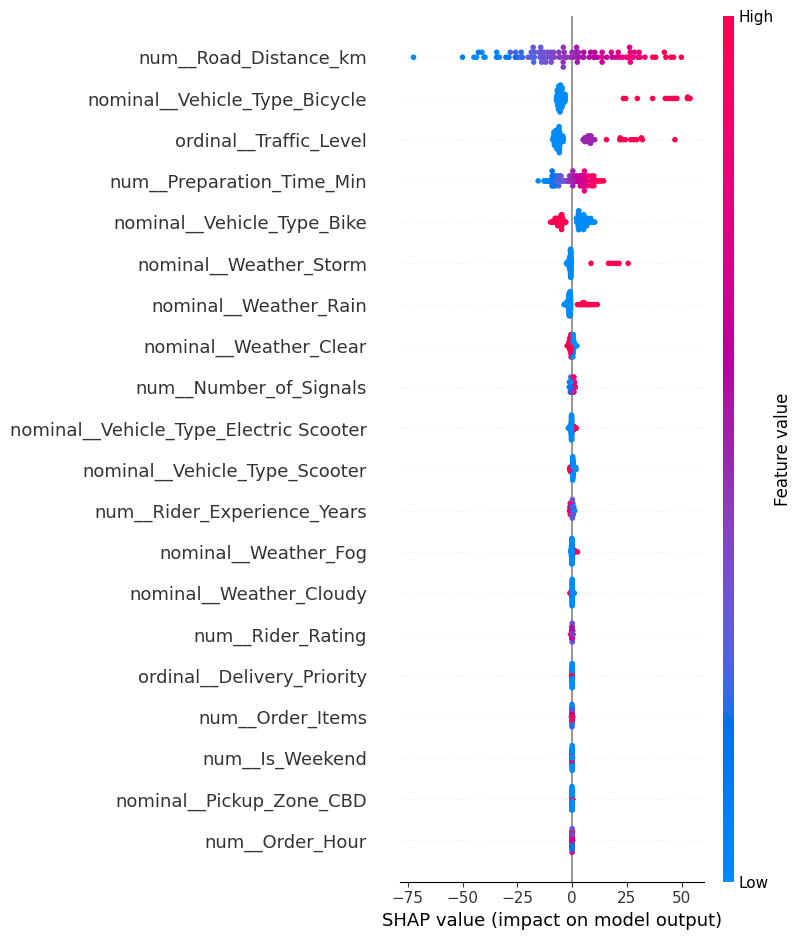

In [ ]:
import shap

# Sample 100-200 random instances from the transformed test set
X_sample = shap.sample(X_test_transformed, 100)  # or use X_test_transformed[:100]

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# Summary plot using the sampled data
# 1. Extract feature names after One-Hot and Ordinal encoding
feature_names = preprocessor.get_feature_names_out()

# 2. Pass feature_names to the summary plot
shap.summary_plot(shap_values, X_sample, feature_names=feature_names)

In [ ]:
import joblib

# Save the trained model pipeline
joblib.dump(best_pipe, '/content/drive/MyDrive/tuned_random_forest_model.pkl')
print("Model saved successfully!")

Model saved successfully!
